In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.chdir('/content/drive/MyDrive/backend/Notebooks/')
!pwd

/content/drive/MyDrive/backend/Notebooks


In [5]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy  as np

import tensorflow as tf
import keras_nlp

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score,
)

from utils import (
    load_data, plot_distribution, plot_text_lengths,
    plot_accuracy, plot_loss, plot_confusion_matrix,
    plot_precision_recall, load_tokenizer,
)

In [6]:
PROJECT_ROOT = '/content/drive/MyDrive/backend'

DATA_DIR      = os.path.join(PROJECT_ROOT, 'Data', 'Generated')
WEIGHTS_DIR   = os.path.join(PROJECT_ROOT, 'Trained_Weights')

os.makedirs(WEIGHTS_DIR, exist_ok=True)


print('PROJECT_ROOT :', PROJECT_ROOT)
print('DATA_DIR     :', DATA_DIR)
print('WEIGHTS_DIR  :', WEIGHTS_DIR)

PROJECT_ROOT : /content/drive/MyDrive/backend
DATA_DIR     : /content/drive/MyDrive/backend/Data/Generated
WEIGHTS_DIR  : /content/drive/MyDrive/backend/Trained_Weights


In [7]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Using GPU: {gpus[0].name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('Using CPU')

Using GPU: /physical_device:GPU:0


In [8]:
CFG = dict(
    model_name   = 'deberta_v3_base_en',
    embedding_name = 'microsoft/deberta-v3-base',
    max_length   = 512,
    batch_size   = 8,
    epochs       = 5,
    lr           = 2e-5,
    warmup_ratio = 0.1,
    val_split    = 0.15,
    test_split   = 0.10,
    num_labels   = 2,
    weight_decay = 0.01,
)

In [10]:
VALID_CSV = os.path.join(DATA_DIR,'combined_dataset.csv')

df = load_data(VALID_CSV)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Dataset successfully loaded from: /content/drive/MyDrive/backend/Data/Generated/combined_dataset.csv
Shape: (1864, 4)
Columns: ['INSTRUCTION', 'reasoning', 'RESPONSE', 'label']


,INSTRUCTION,reasoning,RESPONSE,label
0,Please show me the solution for: Adam goes to ...,"First, let's find the number of students in cl...",37,1
1,Can you explain how to solve this math problem...,To find the total amount of lemonade in the pi...,15,1
2,I'm completely lost with this math problem: Ka...,"Ah, I see exactly how Kantana ended up buying ...",22,0


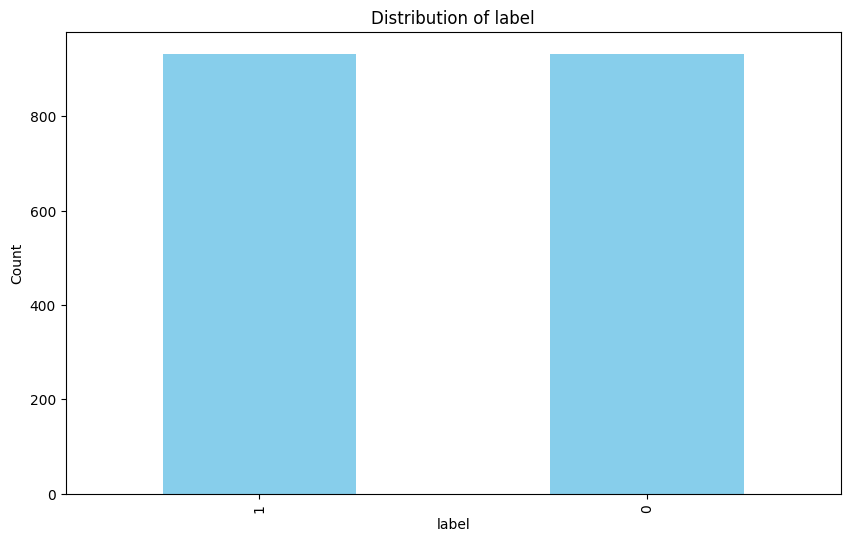

In [11]:
# Label distribution from utils
plot_distribution(df, 'label')

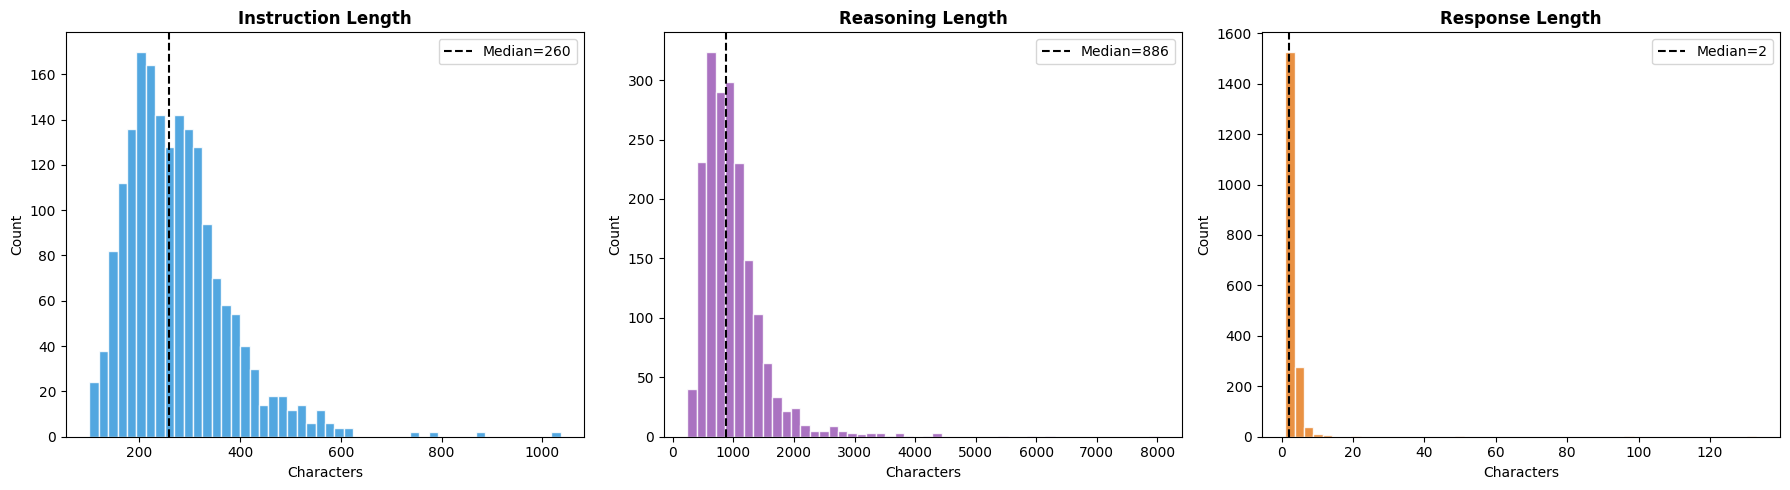

In [12]:
plot_text_lengths(df)

In [13]:
df['label'] = df['label'].astype(int)

df['text'] = (
    df['INSTRUCTION'].astype(str) + '\n' +
    df['reasoning'].astype(str)   + '\n' +
    df['RESPONSE'].astype(str)
)

print(f'Total samples after cleaning: {len(df)}')
print('Sample text (first 200 chars):')
print(df['text'].iloc[0][:200])

Total samples after cleaning: 1864
Sample text (first 200 chars):
Please show me the solution for: Adam goes to a small school, which teaches 80 students in three classes. 40% of the students are in class A, and class B has 21 students fewer than class A. The rest a


In [14]:
train_df, temp_df = train_test_split(
    df[['text', 'label']],
    test_size   = CFG['val_split'] + CFG['test_split'],
    stratify    = df['label'],
    random_state= SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size   = CFG['test_split'] / (CFG['val_split'] + CFG['test_split']),
    stratify    = temp_df['label'],
    random_state= SEED,
)

print(f'Train : {len(train_df):>5} rows')
print(f'Val   : {len(val_df):>5} rows')
print(f'Test  : {len(test_df):>5} rows')

Train :  1398 rows
Val   :   279 rows
Test  :   187 rows


In [15]:
tokenizer = load_tokenizer(CFG["embedding_name"])
print('Tokenizer loaded:', CFG["embedding_name"])
print('Vocab size:', tokenizer.vocab_size)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer loaded: microsoft/deberta-v3-base
Vocab size: 128000


In [16]:
def tokenize_texts(texts, labels, tokenizer, max_length, batch_size, shuffle=False):
    token_ids = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='np',
    )
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            'token_ids':    tf.constant(token_ids['input_ids'],      dtype=tf.int32),
            'padding_mask': tf.constant(token_ids['attention_mask'], dtype=tf.int32),
        },
        tf.constant(list(labels), dtype=tf.int32),
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(texts), seed=SEED)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = tokenize_texts(
    train_df['text'], train_df['label'],
    tokenizer, CFG['max_length'], CFG['batch_size'], shuffle=True
)
val_ds = tokenize_texts(
    val_df['text'], val_df['label'],
    tokenizer, CFG['max_length'], CFG['batch_size']
)
test_ds = tokenize_texts(
    test_df['text'], test_df['label'],
    tokenizer, CFG['max_length'], CFG['batch_size']
)

print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')
print(f'Test  batches : {len(test_ds)}')

Train batches : 175
Val   batches : 35
Test  batches : 24


In [17]:
def load_model(model_name, num_labels=2):
    model = keras_nlp.models.DebertaV3Classifier.from_preset(model_name, preprocessor=None,num_classes=num_labels)
    return model

model = load_model(CFG['model_name'], num_labels=CFG['num_labels'])
model.summary()

Model: "deberta_v3_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deberta_v3_backbone           │ (None, None, 768)         │     183,831,552 │ padding_mask[0][0],        │
│ (DebertaV3Backbone)           │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ deberta_v3_backbone[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 184,423,682 (703.52 MB)

 Trainable params: 184,423,682 (703.52 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
total_steps  = len(train_ds) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])


lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate = CFG['lr'],
    decay_steps           = total_steps - warmup_steps,
    end_learning_rate     = 0.0,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate = lr_schedule,
    weight_decay  = CFG['weight_decay'],
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer= optimizer,
    loss= loss_fn,
    metrics= [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

Total training steps : 875
Warmup steps         : 87


In [19]:
best_model_path = os.path.join(WEIGHTS_DIR, 'deberta_reasoning_best.keras')

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath          = best_model_path,
        monitor           = 'val_accuracy',
        save_best_only    = True,
        save_weights_only = False,
        verbose           = 1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 3,
        restore_best_weights = True,
        verbose              = 1,
    )
]

history_obj = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CFG['epochs'],
    callbacks       = callbacks,
)

history = {
    'train_loss': history_obj.history['loss'],
    'val_loss':   history_obj.history['val_loss'],
    'train_acc':  history_obj.history['accuracy'],
    'val_acc':    history_obj.history['val_accuracy'],
}

print(f'Best Val Accuracy: {max(history["val_acc"]):.4f}')
print(f'Checkpoint: {best_model_path}')

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7736 - loss: 0.4254
Epoch 1: val_accuracy improved from None to 0.97849, saving model to /content/drive/MyDrive/backend/Trained_Weights/deberta_reasoning_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/backend/Trained_Weights/deberta_reasoning_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.8684 - loss: 0.2989 - val_accuracy: 0.9785 - val_loss: 0.0879
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9823 - loss: 0.0643
Epoch 2: val_accuracy did not improve from 0.97849
175/175 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9778 - loss: 0.0766 - val_accuracy: 0.9749 - val_loss: 0.0612
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9874 - loss: 0.0353
Epoch 3: val_accuracy improved from 0.97849 to 0.99283, saving model to /content/drive/MyDrive/backend/Trained_Weights/deberta_reasoning_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive

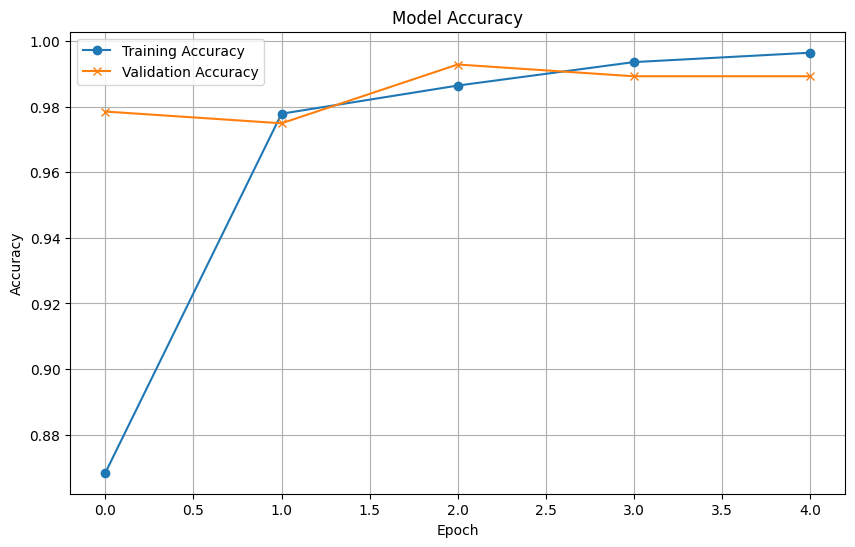

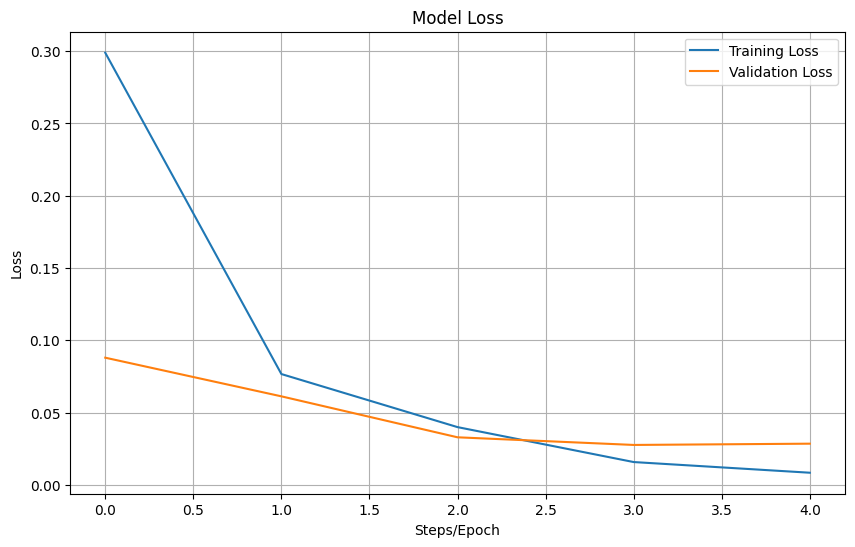

In [20]:
# Training curves
plot_accuracy(history['train_acc'], history['val_acc'])
plot_loss(history['train_loss'],    history['val_loss'])

In [21]:
# Predict on test set
logits_list, labels_list = [], []
for x_batch, y_batch in test_ds:
    logits = model(x_batch, training=False)
    logits_list.append(logits.numpy())
    labels_list.append(y_batch.numpy())

all_logits  = np.concatenate(logits_list, axis=0)
test_labels = np.concatenate(labels_list, axis=0)
test_probs  = tf.nn.softmax(all_logits, axis=-1).numpy()[:, 1]
test_preds  = np.argmax(all_logits, axis=-1)

test_acc = accuracy_score(test_labels, test_preds)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(test_labels, test_probs):.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, labels=[1], target_names=['Valid']))

Test Accuracy : 0.9893
Test ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

       Valid       0.98      1.00      0.99        93

   micro avg       0.98      1.00      0.99        93
   macro avg       0.98      1.00      0.99        93
weighted avg       0.98      1.00      0.99        93



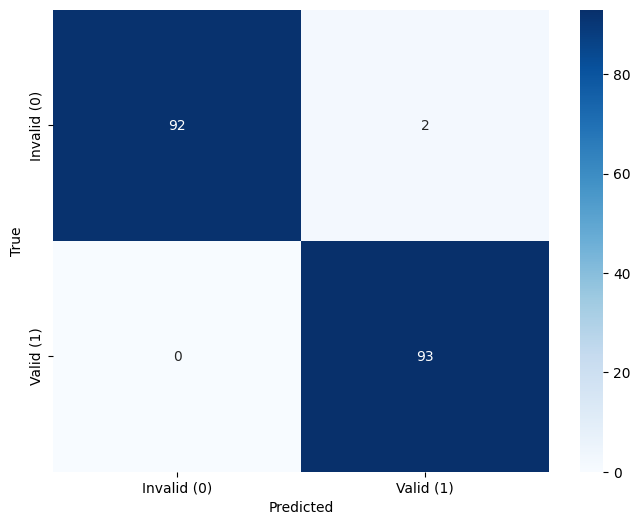

In [22]:
# Confusion matrix
plot_confusion_matrix(test_labels, test_preds, classes=['Invalid (0)', 'Valid (1)'])

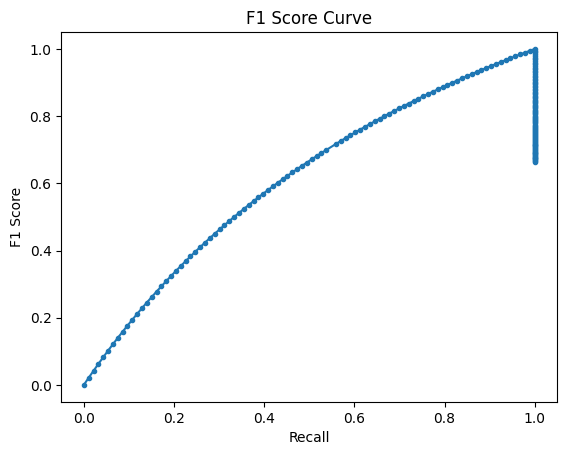

In [23]:
# Precision-Recall / F1 curve
plot_precision_recall(test_labels, test_probs)